## Locating Implied Volatility Jumps to Identify Anomalies in Strike Prices
### Kenneth A. Anderson, Ph.D.

$\textbf{Introduction:}$ Goal of this Project is to Identify Implied Volatility (IV)
 Anomalies in Options Data

$\textbf{Question:}$ Is it possible to systematically detect jumps in IV to inform the selection of strike prices associated with options contracts?

* In this brief coding summary, I describe a six-step Jump Detection procedure that I implemented and refined with AI using real stock options data

$\textbf{Strategy:}$ Leverage functional analysis techniques, specifically the discrete analog of distributional derivatives, to assess changes in implied volatility relative to strike prices
* Distributional derivatives (DDs) are generalizations of classical derivatives, but are well-known for their ability to detect abnormal jumps in functions
sudden jumps from one strike price to the next.
* Analyzed options contracts for Caterpillar (CAT), a mega-cap stock with high IV (~30 days to expiration)
* With a stock like this, high volatility may present opportunities, but could also incur higher transaction costs 


$\textbf{Jump Detector:}$ Leverage second-order finite-differences of IV between neighboring strike prices to detect jumps (normal or abnormal) using the following approach:
  $$ \Delta^2IV = IV_{i+1} - 2IV_i +IV_{i-1}  \approx \frac{d^2}{dS^2}IV(S) $$

## Six-step Procedure

In [9]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
import matplotlib.pyplot as plt

## Step 1. Load and Clean Data

In [10]:
df = pd.read_csv("data/options_data.csv")
df = df.dropna(subset=["Strike", "IV"])       
df = df.sort_values("Strike")

S = df["Strike"].values.astype(float)
iv = df["IV"].values.astype(float)

## Step 2. Define Function to Create a Smooth IV Curve (Median Filtering)

In [11]:
def smooth_iv(iv, kernel=5):
    """Apply a median filter with safe kernel size."""
    kernel = max(3, min(kernel, len(iv) - (1 - len(iv) % 2)))
    return medfilt(iv, kernel_size=kernel)

iv_smooth = smooth_iv(iv, kernel=5)

## Step 3. Compute Second-Order Discrete Derivative

In [12]:
def second_derivative(iv):
    """Return the discrete second derivative array."""
    sec = np.zeros_like(iv)
    for i in range(1, len(iv) - 1):
        sec[i] = iv[i+1] - 2*iv[i] + iv[i-1]
    return sec

iv_dd = second_derivative(iv)

## Step 4. Define the Jump Detector using Customizable Thresholds

In [13]:
def detect_jumps(S, iv_dd, threshold=0.005, min_sep=2):
    """
    Detect IV jumps using second derivative curvature.
    threshold: minimum magnitude of curvature to count as jump.
    min_sep: minimum index separation between jumps.
    """
    jumps = []
    last_idx = -min_sep
    
    for i in range(1, len(iv_dd) - 1):
        if abs(iv_dd[i]) > threshold and (i - last_idx) >= min_sep:
            jumps.append((i, float(S[i]), float(iv_dd[i])))
            last_idx = i
    return jumps

jumps = detect_jumps(S, iv_dd, threshold=0.005)

## Step 5. Plot IV, Smooth IV, and Jumps for Visual Inspection

In [14]:
plt.figure(figsize=(14,5))
plt.plot(S, iv, label="Raw IV", marker="o")
plt.plot(S, iv_smooth, label="Smoothed IV", linewidth=2)

if jumps:
    idx = [j[0] for j in jumps]
    plt.scatter(S[idx], iv[idx], color="red", s=200, label="Detected Jumps")

plt.title("IV Smile with Detected Jumps", fontsize=24)
plt.xlabel("Strike", fontsize=16)
plt.ylabel("Implied Volatility", fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/iv_jumps.png")
#plt.show()
plt.close()


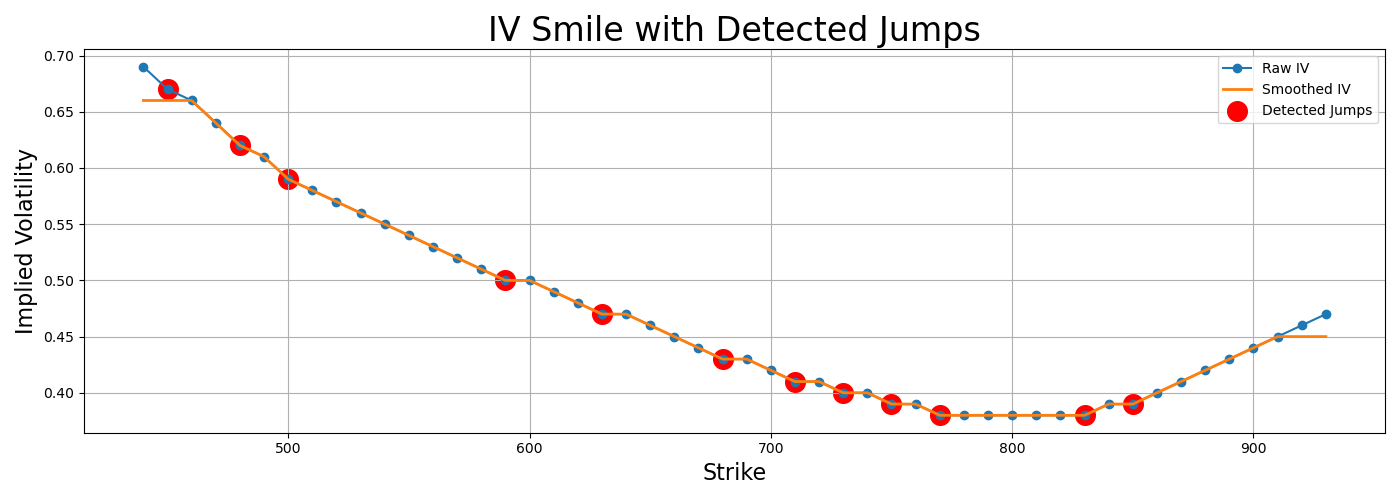

In [15]:
from IPython.display import Image, display
display(Image("images/iv_jumps.png", width="800", height="600"))

## Step 6. Print Jump Table to Review Questionable Strikes

In [16]:
print("\nDetected IV Jumps:")
print("Index | Strike | Δ²IV")
print("-"*30)
for idx, strike, curv in jumps:
    print(f"{idx:5d} | {strike:6.1f} | {curv:+.5f}")


Detected IV Jumps:
Index | Strike | Δ²IV
------------------------------
    1 |  450.0 | +0.01000
    4 |  480.0 | +0.01000
    6 |  500.0 | +0.01000
   15 |  590.0 | +0.01000
   19 |  630.0 | +0.01000
   24 |  680.0 | +0.01000
   27 |  710.0 | +0.01000
   29 |  730.0 | +0.01000
   31 |  750.0 | +0.01000
   33 |  770.0 | +0.01000
   39 |  830.0 | +0.01000
   41 |  850.0 | +0.01000


## Reflections

* The Jump Detection procedure can provide additional quality assurance for individual investors when assessing strike prices
* The clean six-step procedure does not reflect the "graveyard" code
* Overall, no major anomalies were detected in this case, but the procedure does affirm the normal, semi-smooth behavior of implied volatility relative to strike prices
* Jump Detectors may be more useful with small-cap stocks where less consensus about implied volatility may exist



## Next Steps

* Project focused on cross-sectional strikes with contracts that were about a month from expiration;  Analysis of longer times to expiration may be useful
* Normalized version with enhanced filters would enhance the Jump Detector and facilitate comparisons at different time intervals
* Additional APIs and more intense scrutiny of this technique could add value at an enterprise level

GitHub: https://github.com/kennethalonzo/IV_jump-detector-for-options-pricing 